In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Path to dataset files:", path)

c:\Users\marco\.conda\envs\unir\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 346M/346M [00:10<00:00, 35.3MB/s] 

Extracting files...


Path to dataset files: C:\Users\marco\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2


In [ ]:
# Importaciones necesarias
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import random

# Aseguramos reproducibilidad
torch.manual_seed(42)

# Configurar el dispositivo (usará GPU si tienes una compatible, si no, CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")
print(f"¿CUDA disponible?: {torch.cuda.is_available()}")
print(f"Dispositivo actual: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'Ninguno'}")

# Recuperamos la ruta del dataset que ya descargaste
path = kagglehub.dataset_download("puneet6060/intel-image-classification")
print("Ruta base del dataset:", path)

# ATENCIÓN: El dataset de Kaggle suele tener subcarpetas anidadas. 
# Verifica si necesitas añadir "/seg_train/seg_train" o solo "/seg_train"
train_dir = os.path.join(path, 'seg_train', 'seg_train') 
test_dir = os.path.join(path, 'seg_test', 'seg_test')

Usando dispositivo: cuda
¿CUDA disponible?: True
Dispositivo actual: NVIDIA GeForce RTX 4060 Laptop GPU
Ruta base del dataset: C:\Users\marco\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2


In [4]:
# 1. Transformaciones para ENTRENAMIENTO (con aumento de datos)
# Incluye las 5 técnicas requeridas: Resize/Crop, Flip, Rotación, Brillo y Grises
train_transforms = transforms.Compose([
    transforms.Resize((150, 150)),                # Ajuste al tamaño mínimo requerido
    transforms.RandomHorizontalFlip(p=0.5),       # 1. Flip horizontal
    transforms.RandomRotation(degrees=15),        # 2. Rotaciones aleatorias
    transforms.ColorJitter(brightness=0.2),       # 3. Cambios en el brillo
    transforms.RandomGrayscale(p=0.1),            # 4. Escala de grises parcial
    transforms.RandomCrop(150, padding=10),       # 5. Recorte aleatorio (con padding para no perder tamaño)
    transforms.ToTensor()                         # Convertir a tensor
])

# 2. Transformaciones ORIGINALES (solo para visualizar y para test)
# No aplicamos aumento aquí para una evaluación justa
base_transforms = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor()
])

# Carga de Datasets usando ImageFolder
train_dataset_aug = datasets.ImageFolder(root=train_dir, transform=train_transforms)
train_dataset_orig = datasets.ImageFolder(root=train_dir, transform=base_transforms)
test_dataset = datasets.ImageFolder(root=test_dir, transform=base_transforms)

# DataLoaders con lotes de 4 imágenes
batch_size = 4
train_loader_aug = DataLoader(train_dataset_aug, batch_size=batch_size, shuffle=True)
train_loader_orig = DataLoader(train_dataset_orig, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Nombres de las clases
classes = train_dataset_aug.classes
print(f"Clases detectadas: {classes}")

Clases detectadas: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


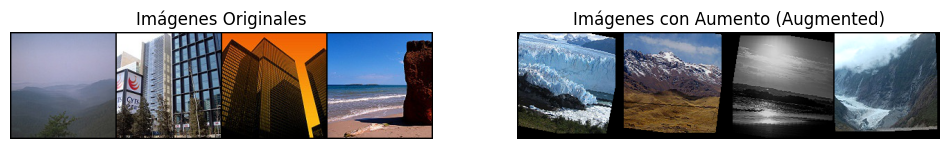

In [5]:
# Función para des-normalizar y mostrar imágenes
def imshow(img, title):
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title(title)
    plt.axis('off')

# Obtenemos un lote de imágenes originales y uno de transformadas
# (Nota: al tener shuffle=True, no serán exactamente las mismas fotos, 
# pero sirve para ver el efecto general del aumento)
dataiter_orig = iter(train_loader_orig)
images_orig, labels_orig = next(dataiter_orig)

dataiter_aug = iter(train_loader_aug)
images_aug, labels_aug = next(dataiter_aug)

# Visualización
fig = plt.figure(figsize=(12, 6))

# Mostrar lote original
ax = fig.add_subplot(1, 2, 1)
import torchvision
imshow(torchvision.utils.make_grid(images_orig), "Imágenes Originales")

# Mostrar lote con aumento
ax = fig.add_subplot(1, 2, 2)
imshow(torchvision.utils.make_grid(images_aug), "Imágenes con Aumento (Augmented)")

plt.show()

In [6]:
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        
        # Capa Convolucional 1
        # Entrada: 3 canales (RGB), Salida: 16 canales
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2) # Reduce de 150x150 a 75x75
        
        # Capa Convolucional 2
        # Entrada: 16 canales, Salida: 32 canales
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2) # Reduce de 75x75 a 37x37
        
        # Capa Totalmente Conectada (Fully Connected)
        # 32 canales * 37 * 37 (dimensiones resultantes)
        self.fc1 = nn.Linear(32 * 37 * 37, 128)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128, 6) # 6 clases de salida
        
    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        
        # Aplanar el tensor para las capas lineales
        x = x.view(-1, 32 * 37 * 37)
        
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        return x

# Instanciamos el modelo y lo enviamos al dispositivo (CPU/GPU)
model = CNNModel().to(device)
print(model)

CNNModel(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=43808, out_features=128, bias=True)
  (relu3): ReLU()
  (fc2): Linear(in_features=128, out_features=6, bias=True)
)


Iniciando el entrenamiento...
Época [1/30] - Pérdida: 1.0916
Época [2/30] - Pérdida: 0.8870
Época [3/30] - Pérdida: 0.8020
Época [4/30] - Pérdida: 0.7479
Época [5/30] - Pérdida: 0.7060
Época [6/30] - Pérdida: 0.6568
Época [7/30] - Pérdida: 0.6343
Época [8/30] - Pérdida: 0.6057
Época [9/30] - Pérdida: 0.5960
Época [10/30] - Pérdida: 0.5758
Época [11/30] - Pérdida: 0.5562
Época [12/30] - Pérdida: 0.5466
Época [13/30] - Pérdida: 0.5393
Época [14/30] - Pérdida: 0.5232
Época [15/30] - Pérdida: 0.5072
Época [16/30] - Pérdida: 0.5038
Época [17/30] - Pérdida: 0.4929
Época [18/30] - Pérdida: 0.4864
Época [19/30] - Pérdida: 0.4793
Época [20/30] - Pérdida: 0.4801
Época [21/30] - Pérdida: 0.4705
Época [22/30] - Pérdida: 0.4659
Época [23/30] - Pérdida: 0.4520
Época [24/30] - Pérdida: 0.4519
Época [25/30] - Pérdida: 0.4440
Época [26/30] - Pérdida: 0.4348
Época [27/30] - Pérdida: 0.4357
Época [28/30] - Pérdida: 0.4336
Época [29/30] - Pérdida: 0.4215
Época [30/30] - Pérdida: 0.4212
¡Entrenamiento fina

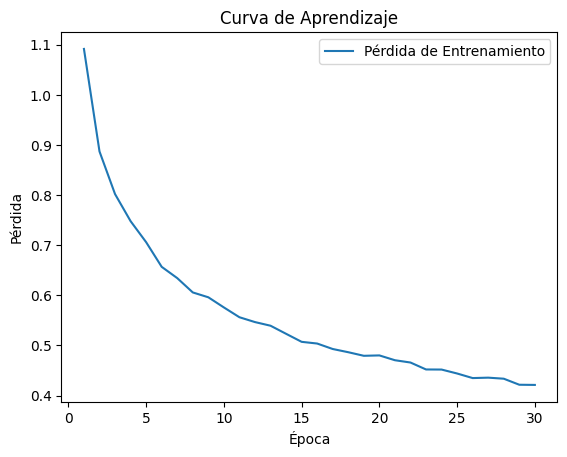

In [7]:
# Criterio de pérdida y Optimizador
criterion = nn.CrossEntropyLoss()
# Adam con learning rate de 0.0001 y weight decay para evitar overfitting
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)

epochs = 30
train_losses = []

print("Iniciando el entrenamiento...")
for epoch in range(epochs):
    model.train() # Modo entrenamiento
    running_loss = 0.0
    
    for i, data in enumerate(train_loader_aug, 0):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)
        
        # 1. Poner gradientes a cero
        optimizer.zero_grad()
        
        # 2. Forward pass (predicción)
        outputs = model(inputs)
        
        # 3. Calcular pérdida
        loss = criterion(outputs, labels)
        
        # 4. Backward pass (retropropagación)
        loss.backward()
        
        # 5. Optimizar pesos
        optimizer.step()
        
        running_loss += loss.item()
        
    # Calcular y mostrar pérdida promedio por época
    epoch_loss = running_loss / len(train_loader_aug)
    train_losses.append(epoch_loss)
    print(f"Época [{epoch+1}/{epochs}] - Pérdida: {epoch_loss:.4f}")

print("¡Entrenamiento finalizado!")

# Gráfica de la pérdida
plt.plot(range(1, epochs+1), train_losses, label='Pérdida de Entrenamiento')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.title('Curva de Aprendizaje')
plt.legend()
plt.show()

In [8]:
model.eval() # Modo evaluación (desactiva Dropout/BatchNorm si los hubiera)
correct = 0
total = 0

# No necesitamos calcular gradientes en la evaluación, ahorra memoria y tiempo
with torch.no_grad():
    for data in test_loader:
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)
        
        outputs = model(inputs)
        
        # Obtenemos la predicción con el valor máximo
        _, predicted = torch.max(outputs.data, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f'Precisión final del modelo en las imágenes de prueba (sin aumento): {accuracy:.2f}%')

Precisión final del modelo en las imágenes de prueba (sin aumento): 84.07%


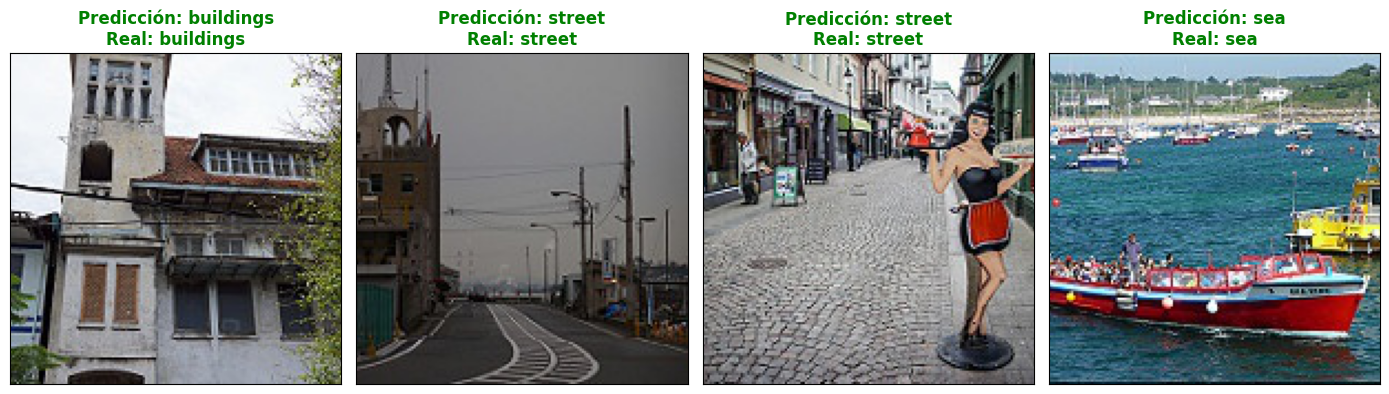

In [25]:
# Nos aseguramos de que el modelo siga en modo evaluación
model.eval() 

# 1. Elegimos 4 índices aleatorios del dataset de prueba completo
indices_aleatorios = random.sample(range(len(test_dataset)), 4)

# 2. Extraemos las imágenes y etiquetas correspondientes a esos índices
images = []
labels = []
for idx in indices_aleatorios:
    img, label = test_dataset[idx]
    images.append(img)
    labels.append(label)

# 3. Agrupamos las listas individuales en tensores (creamos nuestro batch de 4)
images = torch.stack(images)
labels = torch.tensor(labels)

# Movemos los tensores al dispositivo (GPU o CPU)
images_dev = images.to(device)
labels_dev = labels.to(device)

# Realizar las predicciones sin calcular gradientes (ahorra memoria)
with torch.no_grad():
    outputs = model(images_dev)
    # torch.max devuelve el valor máximo y su índice (la clase predicha)
    _, predicted = torch.max(outputs, 1)

# Función auxiliar para convertir el tensor de vuelta a formato de imagen
def imshow_pred(img):
    img = img.cpu() # Mover a CPU por si estaba en la GPU
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))

# Crear una figura para mostrar la cuadrícula de imágenes
fig = plt.figure(figsize=(14, 5))

# Iteramos sobre el número de imágenes
for idx in range(4):
    # Crear subplots (1 fila, 4 columnas)
    ax = fig.add_subplot(1, 4, idx+1, xticks=[], yticks=[])
    imshow_pred(images[idx])
    
    # Obtener los nombres en texto de las clases predichas y reales
    pred_class = classes[predicted[idx]]
    true_class = classes[labels[idx]]
    
    # Pintar de verde si la predicción es correcta, rojo si falló
    color = 'green' if pred_class == true_class else 'red'
    
    # Añadir el título a cada imagen
    ax.set_title(f"Predicción: {pred_class}\nReal: {true_class}", color=color, fontweight='bold')

plt.tight_layout()
plt.show()